In [ ]:
!pip -q install pytorchvideo fvcore iopath

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.7/132.7 kB 11.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 5.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 4.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 67.2 MB/s eta 0:00:00


In [ ]:
from __future__ import annotations

import json
import random
import shutil
import tarfile
import zipfile
from contextlib import nullcontext
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.amp import autocast, GradScaler
from torch.utils.data import DataLoader, Dataset
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModel

from google.colab import drive

drive.mount('/content/drive')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
AMP_ENABLED = DEVICE.type == 'cuda'
amp_ctx = autocast('cuda') if AMP_ENABLED else nullcontext()


PHASE2_RUN_NAME = 'run_003'
PHASE3_RUN_NAME = 'run_003'

PHASE2_ROOT_DRIVE = Path('/content/drive/MyDrive/momentlens_runs/charades_slowfast_phase2') / PHASE2_RUN_NAME
FEATURE_TAR_DRIVE = PHASE2_ROOT_DRIVE / 'features.tar'
FEATURE_MANIFEST_DRIVE = PHASE2_ROOT_DRIVE / 'feature_manifest.json'

STA_ROOT_DRIVE = Path('/content/drive/MyDrive/momentlens_datasets/charades_sta_3fps_v1')
CHARADES_RAW_DRIVE_ROOT = Path('/content/drive/MyDrive/momentlens_datasets/charades_raw_from_scratch')
RAW_VIDEO_ZIP_DRIVE = CHARADES_RAW_DRIVE_ROOT / 'downloads' / 'Charades_v1_480.zip'
STA_LOCAL_ROOT = Path('/content/charades_sta_3fps_v1')
STA_ANNOT_LOCAL = STA_LOCAL_ROOT / 'data' / 'annotations'
STA_SPLIT_LOCAL = STA_LOCAL_ROOT / 'splits'

PHASE3_LOCAL_ROOT = Path('/content/momentlens_runs/charades_vslnet_phase3') / PHASE3_RUN_NAME
PHASE3_DRIVE_ROOT = Path('/content/drive/MyDrive/momentlens_runs/charades_vslnet_phase3') / PHASE3_RUN_NAME
PHASE3_LOCAL_ROOT.mkdir(parents=True, exist_ok=True)
PHASE3_DRIVE_ROOT.mkdir(parents=True, exist_ok=True)
RAW_VIDEO_ZIP_LOCAL = PHASE3_LOCAL_ROOT / 'Charades_v1_480.zip'
RAW_VIDEO_EXTRACT_ROOT = PHASE3_LOCAL_ROOT / 'raw_videos_480p'
RAW_VIDEO_ROOT = RAW_VIDEO_EXTRACT_ROOT / 'Charades_v1_480'
RAW_VIDEO_MARKER = RAW_VIDEO_ROOT / '.extract_done'
RAW_VIDEO_EXTRACT_ROOT.mkdir(parents=True, exist_ok=True)
RAW_VIDEO_ROOT.mkdir(parents=True, exist_ok=True)

ARCHIVE_LOCAL_ROOT = PHASE3_LOCAL_ROOT / 'phase2_archive'
ARCHIVE_FEATURE_ROOT = ARCHIVE_LOCAL_ROOT / 'features'
ARCHIVE_MARKER = ARCHIVE_LOCAL_ROOT / '.tar_extracted'
ARCHIVE_LOCAL_ROOT.mkdir(parents=True, exist_ok=True)

for p in [STA_LOCAL_ROOT, STA_ANNOT_LOCAL, STA_SPLIT_LOCAL]:
    p.mkdir(parents=True, exist_ok=True)

TRAIN_JSON = STA_ANNOT_LOCAL / 'train.json'
VAL_JSON = STA_ANNOT_LOCAL / 'val.json'
TEST_JSON = STA_ANNOT_LOCAL / 'test.json'
TRAIN_VIDEOS = STA_SPLIT_LOCAL / 'train_video_ids.txt'
VAL_VIDEOS = STA_SPLIT_LOCAL / 'val_video_ids.txt'

CONFIG = {
    'epochs': 100,
    'batch_size': 16,
    'num_workers': 12,
    'lr': 1e-4,
    'scheduler_tmax_multiplier': 2.0,
    'scheduler_eta_min': 1e-5,
    'weight_decay': 1e-4,
    'max_query_len': 32,
    'hidden_dim': 128,
    'query_backbone_name': 'distilbert-base-uncased',
    'foreground_alpha': 0.1,
    'dropout': 0.2,
    'foreground_loss_weight': 0.2,
    'grad_clip': 1.0,
    'early_stopping_patience': 12,
    'monitor': 'val_R@1_IoU_0.5',
}

print(json.dumps(CONFIG, indent=2))


Mounted at /content/drive
{
  "epochs": 100,
  "batch_size": 16,
  "num_workers": 12,
  "lr": 0.0001,
  "scheduler_tmax_multiplier": 2.0,
  "scheduler_eta_min": 1e-05,
  "weight_decay": 0.0001,
  "max_query_len": 32,
  "hidden_dim": 128,
  "query_backbone_name": "distilbert-base-uncased",
  "foreground_alpha": 0.1,
  "dropout": 0.2,
  "foreground_loss_weight": 0.2,
  "grad_clip": 1.0,
  "early_stopping_patience": 12,
  "monitor": "val_R@1_IoU_0.5"
}


In [ ]:
def copy_if_missing(src: Path, dst: Path):
    dst.parent.mkdir(parents=True, exist_ok=True)
    if dst.exists() and dst.stat().st_size == src.stat().st_size:
        return
    shutil.copy2(src, dst)

for src, dst in [
    (STA_ROOT_DRIVE / 'data' / 'annotations' / 'train.json', TRAIN_JSON),
    (STA_ROOT_DRIVE / 'data' / 'annotations' / 'val.json', VAL_JSON),
    (STA_ROOT_DRIVE / 'data' / 'annotations' / 'test.json', TEST_JSON),
    (STA_ROOT_DRIVE / 'splits' / 'train_video_ids.txt', TRAIN_VIDEOS),
    (STA_ROOT_DRIVE / 'splits' / 'val_video_ids.txt', VAL_VIDEOS),
    (FEATURE_MANIFEST_DRIVE, ARCHIVE_LOCAL_ROOT / 'feature_manifest.json'),
    (FEATURE_TAR_DRIVE, ARCHIVE_LOCAL_ROOT / 'features.tar'),
    (RAW_VIDEO_ZIP_DRIVE, RAW_VIDEO_ZIP_LOCAL),
]:
    copy_if_missing(src, dst)

print('local STA root:', STA_LOCAL_ROOT)
print('local phase3 root:', PHASE3_LOCAL_ROOT)
print('local archive root:', ARCHIVE_LOCAL_ROOT)


local STA root: /content/charades_sta_3fps_v1
local phase3 root: /content/momentlens_runs/charades_vslnet_phase3/run_003
local archive root: /content/momentlens_runs/charades_vslnet_phase3/run_003/phase2_archive


In [ ]:
if not RAW_VIDEO_MARKER.exists():
    with zipfile.ZipFile(RAW_VIDEO_ZIP_LOCAL, 'r') as zf:
        members = zf.infolist()
        with tqdm(total=len(members), desc='extract charades 480p videos', leave=True) as pbar:
            for member in members:
                zf.extract(member, path=RAW_VIDEO_EXTRACT_ROOT)
                pbar.update(1)
    RAW_VIDEO_MARKER.write_text('done')

feature_tar_local = ARCHIVE_LOCAL_ROOT / 'features.tar'
feature_manifest_local = ARCHIVE_LOCAL_ROOT / 'feature_manifest.json'

if not ARCHIVE_MARKER.exists():
    with tarfile.open(feature_tar_local, 'r') as tf:
        members = tf.getmembers()
        with tqdm(total=len(members), desc='extract phase2 features', leave=True) as pbar:
            for member in members:
                tf.extract(member, path=ARCHIVE_LOCAL_ROOT)
                pbar.update(1)
    ARCHIVE_MARKER.write_text('done')

with feature_manifest_local.open('r', encoding='utf-8') as f:
    phase2_manifest = json.load(f)

print('phase2 splits:', list(phase2_manifest.get('splits', {}).keys()))
print('feature tar:', feature_tar_local)
print('manifest:', feature_manifest_local)


extract charades 480p videos:   0%|          | 0/9849 [00:00<?, ?it/s]

extract phase2 features:   0%|          | 0/6672 [00:00<?, ?it/s]

/tmp/ipykernel_2576/3998111034.py:18: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tf.extract(member, path=ARCHIVE_LOCAL_ROOT)


phase2 splits: ['train', 'val', 'test']
feature tar: /content/momentlens_runs/charades_vslnet_phase3/run_003/phase2_archive/features.tar
manifest: /content/momentlens_runs/charades_vslnet_phase3/run_003/phase2_archive/feature_manifest.json


In [ ]:
def read_json(path: Path):
    with path.open('r', encoding='utf-8') as f:
        return json.load(f)

train_samples = read_json(TRAIN_JSON)
val_samples = read_json(VAL_JSON)
test_samples = read_json(TEST_JSON)

def split_summary(samples, name):
    vids = sorted({s['video_id'] for s in samples})
    print(f'{name}: samples={len(samples)} unique_videos={len(vids)}')
    return vids

split_summary(train_samples, 'train')
split_summary(val_samples, 'val')
split_summary(test_samples, 'test')

all_samples = train_samples + val_samples + test_samples
print('example sample:', train_samples[0])


train: samples=9912 unique_videos=4270
val: samples=2496 unique_videos=1068
test: samples=3720 unique_videos=1334
example sample: {'sample_id': 'train_000000', 'video_id': 'AO8RW', 'query': 'a person is putting a book on a shelf.', 'start': 0.0, 'end': 6.9, 'duration': 34.334, 'metadata_duration': 33.67, 'raw_start': 0.0, 'raw_end': 6.9, 'actual_duration': 34.334, 'duration_source': 'ffprobe'}


In [ ]:
# Build a direct index from feature archive manifest.
feature_path_by_video = {}
for split_name, entries in phase2_manifest.get('splits', {}).items():
    for entry in entries:
        video_id = entry['video_id']
        feature_path = ARCHIVE_FEATURE_ROOT / split_name / f'{video_id}.pt'
        feature_path_by_video[(split_name, video_id)] = feature_path

# Sanity check with one sample.
sample_video_id = train_samples[0]['video_id']
sample_path = feature_path_by_video[('train', sample_video_id)]

sample_bundle = torch.load(sample_path, map_location='cpu')
FEATURE_DIM = int(sample_bundle['feature_dim'])
print('sample feature path:', sample_path)
print('feature keys:', list(sample_bundle.keys()))
print('feature shape:', tuple(sample_bundle['features'].shape))
print('feature dim:', FEATURE_DIM)
print('num windows:', sample_bundle['num_windows'])
print('feature_clip_len_sec:', sample_bundle.get('feature_clip_len_sec'))
print('video_timeline_fps:', sample_bundle.get('video_timeline_fps'))
print('num_frames:', sample_bundle.get('num_frames'))

# Preload the full feature archive into RAM once so workers don't keep hitting disk.
FEATURE_BANK = {}
feature_items = list(feature_path_by_video.items())
with tqdm(total=len(feature_items), desc='preload features', leave=True) as pbar:
    for key, feature_path in feature_items:
        FEATURE_BANK[key] = torch.load(feature_path, map_location='cpu')
        pbar.update(1)
print('preloaded feature bundles:', len(FEATURE_BANK))


sample feature path: /content/momentlens_runs/charades_vslnet_phase3/run_003/phase2_archive/features/train/AO8RW.pt
feature keys: ['video_id', 'split', 'video_path', 'video_length_sec', 'clip_starts', 'clip_ends', 'features', 'feature_dim', 'num_windows', 'source_checkpoint', 'feature_clip_len_sec', 'num_frames', 'video_timeline_fps']
feature shape: (34, 2304)
feature dim: 2304
num windows: 34
feature_clip_len_sec: 1.0
video_timeline_fps: 24.0
num_frames: 32


preload features:   0%|          | 0/6672 [00:00<?, ?it/s]

preloaded feature bundles: 6672


In [ ]:
query_tokenizer = AutoTokenizer.from_pretrained(CONFIG['query_backbone_name'])
print('query backbone:', CONFIG['query_backbone_name'])
print('query tokenizer max length:', CONFIG['max_query_len'])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

query backbone: distilbert-base-uncased
query tokenizer max length: 32


In [ ]:
def load_feature_bundle(split_name: str, video_id: str):
    return FEATURE_BANK[(split_name, video_id)]


def build_hard_target(centers: torch.Tensor, target_sec: float, mask: torch.Tensor):
    valid_centers = centers.masked_fill(~mask, float('inf'))
    idx = torch.argmin((valid_centers - target_sec).abs())
    target = torch.zeros_like(centers)
    target[idx] = 1.0
    return target


class CharadesStaFeatureDataset(Dataset):
    def __init__(self, samples, split_name: str):
        self.samples = samples
        self.split_name = split_name

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        bundle = load_feature_bundle(self.split_name, sample['video_id'])
        features = bundle['features'].to(torch.float32)
        clip_starts = bundle['clip_starts'].to(torch.float32)
        clip_ends = bundle['clip_ends'].to(torch.float32)
        centers = 0.5 * (clip_starts + clip_ends)
        mask = torch.ones(features.shape[0], dtype=torch.bool)

        encoded = query_tokenizer(
            sample['query'],
            padding='max_length',
            truncation=True,
            max_length=CONFIG['max_query_len'],
            return_tensors='pt',
        )
        query_input_ids = encoded['input_ids'].squeeze(0)
        query_attention_mask = encoded['attention_mask'].squeeze(0)
        start_target = build_hard_target(centers, float(sample['start']), mask)
        end_target = build_hard_target(centers, float(sample['end']), mask)
        moment_start = float(sample['start'])
        moment_end = float(sample['end'])
        moment_len = max(moment_end - moment_start, 1e-6)
        alpha = CONFIG['foreground_alpha']
        fg_start = moment_start - alpha * moment_len
        fg_end = moment_end + alpha * moment_len
        inter = torch.clamp(torch.minimum(clip_ends, torch.tensor(fg_end)) - torch.maximum(clip_starts, torch.tensor(fg_start)), min=0.0)
        foreground_target = (inter > 0).float()

        return {
            'video_id': sample['video_id'],
            'query': sample['query'],
            'start_time': float(sample['start']),
            'end_time': float(sample['end']),
            'duration': float(sample['duration']),
            'features': features,
            'centers': centers,
            'mask': mask,
            'query_input_ids': query_input_ids,
            'query_attention_mask': query_attention_mask,
            'start_target': start_target,
            'end_target': end_target,
            'foreground_target': foreground_target,
        }


def collate_batch(batch):
    max_t = max(item['features'].shape[0] for item in batch)
    feat_dim = batch[0]['features'].shape[-1]
    max_q = max(item['query_input_ids'].shape[0] for item in batch)

    features = torch.zeros(len(batch), max_t, feat_dim, dtype=torch.float32)
    centers = torch.zeros(len(batch), max_t, dtype=torch.float32)
    video_mask = torch.zeros(len(batch), max_t, dtype=torch.bool)
    query_input_ids = torch.zeros(len(batch), max_q, dtype=torch.long)
    query_attention_mask = torch.zeros(len(batch), max_q, dtype=torch.long)
    start_target = torch.zeros(len(batch), max_t, dtype=torch.float32)
    end_target = torch.zeros(len(batch), max_t, dtype=torch.float32)
    foreground_target = torch.zeros(len(batch), max_t, dtype=torch.float32)

    meta = {'video_id': [], 'query': [], 'start_time': [], 'end_time': [], 'duration': []}

    for i, item in enumerate(batch):
        t = item['features'].shape[0]
        q = item['query_input_ids'].shape[0]
        features[i, :t] = item['features']
        centers[i, :t] = item['centers']
        video_mask[i, :t] = True
        query_input_ids[i, :q] = item['query_input_ids']
        query_attention_mask[i, :q] = item['query_attention_mask']
        start_target[i, :t] = item['start_target']
        end_target[i, :t] = item['end_target']
        foreground_target[i, :t] = item['foreground_target']
        meta['video_id'].append(item['video_id'])
        meta['query'].append(item['query'])
        meta['start_time'].append(item['start_time'])
        meta['end_time'].append(item['end_time'])
        meta['duration'].append(item['duration'])

    meta = {k: torch.tensor(v, dtype=torch.float32) if k != 'video_id' and k != 'query' else v for k, v in meta.items()}
    return {
        'features': features,
        'centers': centers,
        'video_mask': video_mask,
        'query_input_ids': query_input_ids,
        'query_attention_mask': query_attention_mask,
        'start_target': start_target,
        'end_target': end_target,
        'foreground_target': foreground_target,
        **meta,
    }

train_ds = CharadesStaFeatureDataset(train_samples, 'train')
val_ds = CharadesStaFeatureDataset(val_samples, 'val')
test_ds = CharadesStaFeatureDataset(test_samples, 'test')

dataloader_kwargs = dict(
    batch_size=CONFIG['batch_size'],
    num_workers=CONFIG['num_workers'],
    pin_memory=True,
    persistent_workers=CONFIG['num_workers'] > 0,
    collate_fn=collate_batch,
)
if CONFIG['num_workers'] > 0:
    dataloader_kwargs['prefetch_factor'] = 4

train_loader = DataLoader(train_ds, shuffle=True, **dataloader_kwargs)
val_loader = DataLoader(val_ds, shuffle=False, **dataloader_kwargs)
test_loader = DataLoader(test_ds, shuffle=False, **dataloader_kwargs)

print('train batches:', len(train_loader))
print('val batches:', len(val_loader))
print('test batches:', len(test_loader))


train batches: 620
val batches: 156
test batches: 233


In [ ]:
class SharedFeatureEncoder(nn.Module):
    def __init__(self, hidden_dim: int, dropout: float = 0.2, num_heads: int = 8):
        super().__init__()
        self.convs = nn.ModuleList([
            nn.Conv1d(hidden_dim, hidden_dim, kernel_size=7, padding=3)
            for _ in range(4)
        ])
        self.conv_norms = nn.ModuleList([
            nn.LayerNorm(hidden_dim)
            for _ in range(4)
        ])
        self.self_attn = nn.MultiheadAttention(hidden_dim, num_heads, dropout=dropout, batch_first=True)
        self.self_attn_norm = nn.LayerNorm(hidden_dim)
        self.ffn = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
        )
        self.ffn_norm = nn.LayerNorm(hidden_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        # x: [B, T, D]
        h = x
        mask_f = None if mask is None else mask.unsqueeze(-1).float()
        key_padding_mask = None if mask is None else ~mask.bool()

        if mask_f is not None:
            h = h * mask_f

        for conv, norm in zip(self.convs, self.conv_norms):
            y = conv(h.transpose(1, 2)).transpose(1, 2)
            h = norm(h + self.dropout(y))
            h = F.relu(h)
            if mask_f is not None:
                h = h * mask_f

        y, _ = self.self_attn(h, h, h, key_padding_mask=key_padding_mask, need_weights=False)
        h = self.self_attn_norm(h + self.dropout(y))

        y = self.ffn(h)
        h = self.ffn_norm(h + self.dropout(y))

        if mask_f is not None:
            h = h * mask_f
        return h


class CrossModalGroundingModel(nn.Module):
    def __init__(self, feature_dim: int, hidden_dim: int = 128, query_backbone_name: str = 'distilbert-base-uncased', dropout: float = 0.2):
        super().__init__()
        self.query_backbone_name = query_backbone_name
        self.query_backbone = AutoModel.from_pretrained(query_backbone_name)
        for p in self.query_backbone.parameters():
            p.requires_grad = False
        self.query_backbone.eval()

        query_hidden_dim = getattr(self.query_backbone.config, 'hidden_size', None)
        if query_hidden_dim is None:
            query_hidden_dim = getattr(self.query_backbone.config, 'dim', None)
        if query_hidden_dim is None:
            raise ValueError('Unable to infer query hidden size from pretrained model config')

        self.query_input_proj = nn.Linear(query_hidden_dim, hidden_dim)
        self.video_input_proj = nn.Linear(feature_dim, hidden_dim)
        self.shared_feature_encoder = SharedFeatureEncoder(hidden_dim, dropout=dropout)

        self.vsl_interaction_ffn = nn.Sequential(
            nn.Linear(hidden_dim * 4, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        self.foreground_gate_conv = nn.Conv1d(hidden_dim * 2, 1, kernel_size=7, padding=3)

        self.start_lstm = nn.LSTM(
            input_size=hidden_dim,
            hidden_size=hidden_dim // 2,
            num_layers=1,
            batch_first=True,
            bidirectional=False,
        )
        self.end_lstm = nn.LSTM(
            input_size=hidden_dim + hidden_dim // 2,
            hidden_size=hidden_dim // 2,
            num_layers=1,
            batch_first=True,
            bidirectional=False,
        )

        self.start_head = nn.Sequential(
            nn.Linear(hidden_dim // 2 + hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),
        )
        self.end_head = nn.Sequential(
            nn.Linear(hidden_dim // 2 + hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),
        )

    def train(self, mode=True):
        super().train(mode)
        self.query_backbone.eval()
        return self

    def encode_query(self, input_ids, attention_mask):
        with torch.no_grad():
            outputs = self.query_backbone(input_ids=input_ids, attention_mask=attention_mask)
        q = self.query_input_proj(outputs.last_hidden_state)
        q = self.shared_feature_encoder(q, attention_mask.bool())
        mask = attention_mask.float().unsqueeze(-1)
        pooled = (q * mask).sum(dim=1) / mask.sum(dim=1).clamp_min(1.0)
        return q, pooled

    def forward(self, features, video_mask, input_ids, attention_mask):
        bsz, t, _ = features.shape
        v = self.video_input_proj(features)
        v = self.shared_feature_encoder(v, video_mask)

        q_tokens, q_summary = self.encode_query(input_ids, attention_mask)
        q_mask = attention_mask.bool()

        similarity_scores = torch.matmul(v, q_tokens.transpose(1, 2)) / (v.size(-1) ** 0.5)
        sim_q = similarity_scores.masked_fill(~q_mask[:, None, :], float('-inf'))
        attn_q = F.softmax(sim_q, dim=-1)
        context_to_query = torch.matmul(attn_q, q_tokens)

        ctx_score = similarity_scores.max(dim=-1).values.masked_fill(~video_mask, float('-inf'))
        ctx_weight = F.softmax(ctx_score, dim=-1)
        global_video_context = torch.matmul(ctx_weight.unsqueeze(1), v).expand(-1, t, -1)

        video_query_features = self.vsl_interaction_ffn(torch.cat([v, context_to_query, v * context_to_query, v * global_video_context], dim=-1))
        hq = q_summary
        foreground_input = torch.cat([video_query_features, hq.unsqueeze(1).expand(-1, t, -1)], dim=-1)
        foreground_logits = self.foreground_gate_conv(foreground_input.transpose(1, 2)).transpose(1, 2).squeeze(-1)
        foreground_gate = torch.sigmoid(foreground_logits)
        foreground_features = foreground_gate.unsqueeze(-1) * video_query_features

        lengths = video_mask.sum(dim=1).clamp_min(1).to(torch.long).cpu()
        packed_start = pack_padded_sequence(foreground_features, lengths, batch_first=True, enforce_sorted=False)
        packed_start_out, _ = self.start_lstm(packed_start)
        start_states, _ = pad_packed_sequence(packed_start_out, batch_first=True, total_length=t)

        start_logits = self.start_head(torch.cat([start_states, foreground_features], dim=-1)).squeeze(-1)

        end_input = torch.cat([foreground_features, start_states], dim=-1)
        packed_end = pack_padded_sequence(end_input, lengths, batch_first=True, enforce_sorted=False)
        packed_end_out, _ = self.end_lstm(packed_end)
        end_states, _ = pad_packed_sequence(packed_end_out, batch_first=True, total_length=t)
        end_logits = self.end_head(torch.cat([end_states, foreground_features], dim=-1)).squeeze(-1)

        neg_fill = torch.finfo(start_logits.dtype).min
        start_logits = start_logits.masked_fill(~video_mask, neg_fill)
        end_logits = end_logits.masked_fill(~video_mask, neg_fill)
        foreground_logits = foreground_logits.masked_fill(~video_mask, neg_fill)
        return start_logits, end_logits, foreground_logits


model = CrossModalGroundingModel(
    feature_dim=FEATURE_DIM,
    hidden_dim=CONFIG['hidden_dim'],
    query_backbone_name=CONFIG['query_backbone_name'],
    dropout=CONFIG['dropout'],
).to(DEVICE)

print(model.__class__.__name__)
print('trainable params:', sum(p.numel() for p in model.parameters() if p.requires_grad))


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


CrossModalGroundingModel
trainable params: 1186435


In [ ]:
def masked_soft_cross_entropy(logits, target, mask):
    target = target * mask.float()
    target = target / target.sum(dim=-1, keepdim=True).clamp_min(1e-8)
    log_probs = F.log_softmax(logits, dim=-1)
    return (-(target * log_probs).sum(dim=-1)).mean()


def masked_bce_with_logits(logits, target, mask):
    loss = F.binary_cross_entropy_with_logits(logits, target, reduction='none')
    loss = loss * mask.float()
    return loss.sum() / mask.float().sum().clamp_min(1.0)


def select_span(start_logits, end_logits, video_mask):
    start_probs = F.softmax(start_logits, dim=-1)
    end_probs = F.softmax(end_logits, dim=-1)
    score = start_probs[:, :, None] * end_probs[:, None, :]

    bsz, t, _ = score.shape
    idx = torch.arange(t, device=score.device)
    tri_mask = idx[None, :, None] <= idx[None, None, :]
    valid = tri_mask.expand(bsz, -1, -1) & video_mask[:, :, None] & video_mask[:, None, :]

    score = score.masked_fill(~valid, float('-inf'))
    flat = score.view(bsz, -1)
    best = flat.argmax(dim=-1)
    has_valid = valid.view(bsz, -1).any(dim=-1)

    fallback_start = start_probs.masked_fill(~video_mask, float('-inf')).argmax(dim=-1)
    fallback_end_scores = end_probs.masked_fill(~video_mask, float('-inf'))
    fallback_end_scores = fallback_end_scores.masked_fill(idx[None, :] < fallback_start[:, None], float('-inf'))
    fallback_end = fallback_end_scores.argmax(dim=-1)

    start = best // t
    end = best % t
    if not has_valid.all():
        start = torch.where(has_valid, start, fallback_start)
        end = torch.where(has_valid, end, fallback_end)
    return start, end


def temporal_iou(pred_start, pred_end, gt_start, gt_end):
    inter = torch.clamp(torch.minimum(pred_end, gt_end) - torch.maximum(pred_start, gt_start), min=0.0)
    union = torch.maximum(pred_end, gt_end) - torch.minimum(pred_start, gt_start)
    return torch.where(union > 0, inter / union, torch.zeros_like(union))


def run_eval(model, loader, collect_records=False, prefix='val'):
    model.eval()
    total = 0
    iou_sum = 0.0
    hit_03 = 0
    hit_05 = 0
    hit_07 = 0
    loss_sum = 0.0
    loss_steps = 0
    records = []
    sample_idx = 0

    with torch.inference_mode():
        for batch in tqdm(loader, desc='eval', leave=False):
            features = batch['features'].to(DEVICE, non_blocking=True)
            video_mask = batch['video_mask'].to(DEVICE, non_blocking=True)
            query_input_ids = batch['query_input_ids'].to(DEVICE, non_blocking=True)
            query_attention_mask = batch['query_attention_mask'].to(DEVICE, non_blocking=True)
            centers = batch['centers'].to(DEVICE, non_blocking=True)
            start_target = batch['start_target'].to(DEVICE, non_blocking=True)
            end_target = batch['end_target'].to(DEVICE, non_blocking=True)
            foreground_target = batch['foreground_target'].to(DEVICE, non_blocking=True)
            start_time = batch['start_time'].to(DEVICE, non_blocking=True)
            end_time = batch['end_time'].to(DEVICE, non_blocking=True)

            with amp_ctx:
                start_logits, end_logits, foreground_logits = model(features, video_mask, query_input_ids, query_attention_mask)
            loss_start = masked_soft_cross_entropy(start_logits, start_target, video_mask)
            loss_end = masked_soft_cross_entropy(end_logits, end_target, video_mask)
            loss_highlight = masked_bce_with_logits(foreground_logits, foreground_target, video_mask)
            batch_loss = loss_start + loss_end + CONFIG['foreground_loss_weight'] * loss_highlight
            loss_sum += float(batch_loss.item())
            loss_steps += 1

            start_idx, end_idx = select_span(start_logits, end_logits, video_mask)
            pred_start = centers.gather(1, start_idx.unsqueeze(1)).squeeze(1)
            pred_end = centers.gather(1, end_idx.unsqueeze(1)).squeeze(1)
            iou = temporal_iou(pred_start, pred_end, start_time, end_time)

            total += int(iou.numel())
            iou_sum += float(iou.sum().item())
            hit_03 += int((iou >= 0.3).sum().item())
            hit_05 += int((iou >= 0.5).sum().item())
            hit_07 += int((iou >= 0.7).sum().item())

            if collect_records:
                pred_start_cpu = pred_start.tolist()
                pred_end_cpu = pred_end.tolist()
                iou_cpu = iou.tolist()
                start_time_cpu = start_time.tolist()
                end_time_cpu = end_time.tolist()
                for k in range(len(pred_start_cpu)):
                    records.append({
                        'sample_idx': sample_idx,
                        'sample_id': f"{batch['video_id'][k]}_{sample_idx:06d}",
                        'video_id': batch['video_id'][k],
                        'query': batch['query'][k],
                        'gt_start': float(start_time_cpu[k]),
                        'gt_end': float(end_time_cpu[k]),
                        'pred_start': float(pred_start_cpu[k]),
                        'pred_end': float(pred_end_cpu[k]),
                        'iou': float(iou_cpu[k]),
                        'duration': float(batch['duration'][k].item()),
                    })
                    sample_idx += 1
            else:
                sample_idx += len(pred_start)

    metrics = {
        f'{prefix}_loss': loss_sum / max(1, loss_steps),
        f'{prefix}_mIoU': iou_sum / max(1, total),
        f'{prefix}_R@1_IoU_0.3': hit_03 / max(1, total),
        f'{prefix}_R@1_IoU_0.5': hit_05 / max(1, total),
        f'{prefix}_R@1_IoU_0.7': hit_07 / max(1, total),
    }
    metrics[f'{prefix}_mAP_proxy'] = (metrics[f'{prefix}_R@1_IoU_0.3'] + metrics[f'{prefix}_R@1_IoU_0.5'] + metrics[f'{prefix}_R@1_IoU_0.7']) / 3.0
    return (metrics, records) if collect_records else metrics


def run_train_one_epoch(model, loader, optimizer, scaler):
    model.train()
    total_loss = 0.0
    pbar = tqdm(loader, desc='train', leave=False)
    for batch in pbar:
        features = batch['features'].to(DEVICE, non_blocking=True)
        video_mask = batch['video_mask'].to(DEVICE, non_blocking=True)
        query_input_ids = batch['query_input_ids'].to(DEVICE, non_blocking=True)
        query_attention_mask = batch['query_attention_mask'].to(DEVICE, non_blocking=True)
        start_target = batch['start_target'].to(DEVICE, non_blocking=True)
        end_target = batch['end_target'].to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with amp_ctx:
            start_logits, end_logits, foreground_logits = model(features, video_mask, query_input_ids, query_attention_mask)
            loss_start = masked_soft_cross_entropy(start_logits, start_target, video_mask)
            loss_end = masked_soft_cross_entropy(end_logits, end_target, video_mask)
            loss_highlight = masked_bce_with_logits(foreground_logits, batch['foreground_target'].to(DEVICE, non_blocking=True), video_mask)
            loss = loss_start + loss_end + CONFIG['foreground_loss_weight'] * loss_highlight

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG['grad_clip'])
        scaler.step(optimizer)
        scaler.update()

        total_loss += float(loss.item())
        pbar.set_postfix(loss=f'{loss.item():.4f}')

    return total_loss / max(1, len(loader))


In [ ]:
EPOCHS = CONFIG['epochs']

def build_param_groups(model):
    decay = []
    no_decay = []
    no_decay_keywords = ('bias', 'ln_', 'layernorm', 'norm')
    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        is_no_decay = any(key in name.lower() for key in no_decay_keywords)
        if is_no_decay:
            no_decay.append(param)
        else:
            decay.append(param)
    return [
        {'params': decay, 'lr': CONFIG['lr'], 'weight_decay': CONFIG['weight_decay']},
        {'params': no_decay, 'lr': CONFIG['lr'], 'weight_decay': 0.0},
    ]

optimizer = torch.optim.AdamW(build_param_groups(model))
scheduler_tmax = max(1, int(EPOCHS * CONFIG['scheduler_tmax_multiplier']))
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=scheduler_tmax,
    eta_min=CONFIG['scheduler_eta_min'],
)
scaler = GradScaler('cuda', enabled=AMP_ENABLED)

RUN_ROOT = PHASE3_DRIVE_ROOT
RUN_ROOT.mkdir(parents=True, exist_ok=True)
LOCAL_RUN_ROOT = PHASE3_LOCAL_ROOT

with open(LOCAL_RUN_ROOT / 'config.json', 'w') as f:
    json.dump(CONFIG, f, indent=2)
shutil.copy2(LOCAL_RUN_ROOT / 'config.json', RUN_ROOT / 'config.json')
shutil.copy2(feature_manifest_local, RUN_ROOT / 'phase2_feature_manifest.json')

print('run root:', RUN_ROOT)
print('scheduler T_max:', scheduler_tmax)
print('eta_min:', CONFIG['scheduler_eta_min'])
print('monitor:', CONFIG['monitor'])


run root: /content/drive/MyDrive/momentlens_runs/charades_vslnet_phase3/run_003
scheduler T_max: 200
eta_min: 1e-05
monitor: val_R@1_IoU_0.5


In [ ]:
history = []
best_metric = -1.0
best_path = RUN_ROOT / 'best.pt'
epochs_without_improvement = 0
patience = CONFIG['early_stopping_patience']

for epoch in range(1, EPOCHS + 1):
    train_loss = run_train_one_epoch(model, train_loader, optimizer, scaler)
    val_metrics = run_eval(model, val_loader, prefix='val')
    record = {'epoch': epoch, 'train_loss': train_loss, **val_metrics}
    history.append(record)
    print(json.dumps(record, indent=2))
    scheduler.step()

    metric_value = float(val_metrics[CONFIG['monitor']])
    if metric_value > best_metric:
        best_metric = metric_value
        epochs_without_improvement = 0
        torch.save(model.state_dict(), LOCAL_RUN_ROOT / 'best.pt')
        shutil.copy2(LOCAL_RUN_ROOT / 'best.pt', best_path)
        print(f'  saved new best: {best_metric:.4f}')
    else:
        epochs_without_improvement += 1

    with open(LOCAL_RUN_ROOT / 'history.json', 'w') as f:
        json.dump(history, f, indent=2)
    shutil.copy2(LOCAL_RUN_ROOT / 'history.json', RUN_ROOT / 'history.json')

    if epochs_without_improvement >= patience:
        print(f'early stopping triggered after {patience} stale epochs')
        break

print('best metric:', best_metric)
print('best path:', best_path)


train:   0%|          | 0/620 [00:00<?, ?it/s]

eval:   0%|          | 0/156 [00:00<?, ?it/s]

{
  "epoch": 1,
  "train_loss": 6.293344063143576,
  "val_loss": 5.968019665815891,
  "val_mIoU": 0.34905691578602177,
  "val_R@1_IoU_0.3": 0.5120192307692307,
  "val_R@1_IoU_0.5": 0.2299679487179487,
  "val_R@1_IoU_0.7": 0.11738782051282051,
  "val_mAP_proxy": 0.2864583333333333
}
  saved new best: 0.2300


train:   0%|          | 0/620 [00:00<?, ?it/s]

eval:   0%|          | 0/156 [00:00<?, ?it/s]

...

eval:   0%|          | 0/156 [00:00<?, ?it/s]

{
  "epoch": 30,
  "train_loss": 2.3915715425245225,
  "val_loss": 7.807492635188958,
  "val_mIoU": 0.4323663202424844,
  "val_R@1_IoU_0.3": 0.6374198717948718,
  "val_R@1_IoU_0.5": 0.4579326923076923,
  "val_R@1_IoU_0.7": 0.2644230769230769,
  "val_mAP_proxy": 0.453258547008547
}


train:   0%|          | 0/620 [00:00<?, ?it/s]

eval:   0%|          | 0/156 [00:00<?, ?it/s]

{
  "epoch": 31,
  "train_loss": 2.269289133144963,
  "val_loss": 8.637280635344677,
  "val_mIoU": 0.4296954211134177,
  "val_R@1_IoU_0.3": 0.624198717948718,
  "val_R@1_IoU_0.5": 0.46153846153846156,
  "val_R@1_IoU_0.7": 0.2704326923076923,
  "val_mAP_proxy": 0.45205662393162394
}
early stopping triggered after 12 stale epochs
best metric: 0.47876602564102566
best path: /content/drive/MyDrive/momentlens_runs/charades_vslnet_phase3/run_003/best.pt


In [ ]:
best_state = torch.load(best_path, map_location=DEVICE)
model.load_state_dict(best_state)
test_metrics, test_records = run_eval(model, test_loader, collect_records=True, prefix='test')
print(json.dumps(test_metrics, indent=2))

with open(LOCAL_RUN_ROOT / 'test_metrics.json', 'w') as f:
    json.dump(test_metrics, f, indent=2)
with open(LOCAL_RUN_ROOT / 'test_records.json', 'w') as f:
    json.dump(test_records, f, indent=2)
shutil.copy2(LOCAL_RUN_ROOT / 'test_metrics.json', RUN_ROOT / 'test_metrics.json')
shutil.copy2(LOCAL_RUN_ROOT / 'test_records.json', RUN_ROOT / 'test_records.json')

print('saved test metrics:', RUN_ROOT / 'test_metrics.json')
print('saved test records:', RUN_ROOT / 'test_records.json')


eval:   0%|          | 0/233 [00:00<?, ?it/s]

{
  "test_loss": 6.954595111470366,
  "test_mIoU": 0.4116521797513449,
  "test_R@1_IoU_0.3": 0.6080645161290322,
  "test_R@1_IoU_0.5": 0.42768817204301074,
  "test_R@1_IoU_0.7": 0.24193548387096775,
  "test_mAP_proxy": 0.4258960573476702
}
saved test metrics: /content/drive/MyDrive/momentlens_runs/charades_vslnet_phase3/run_003/test_metrics.json
saved test records: /content/drive/MyDrive/momentlens_runs/charades_vslnet_phase3/run_003/test_records.json


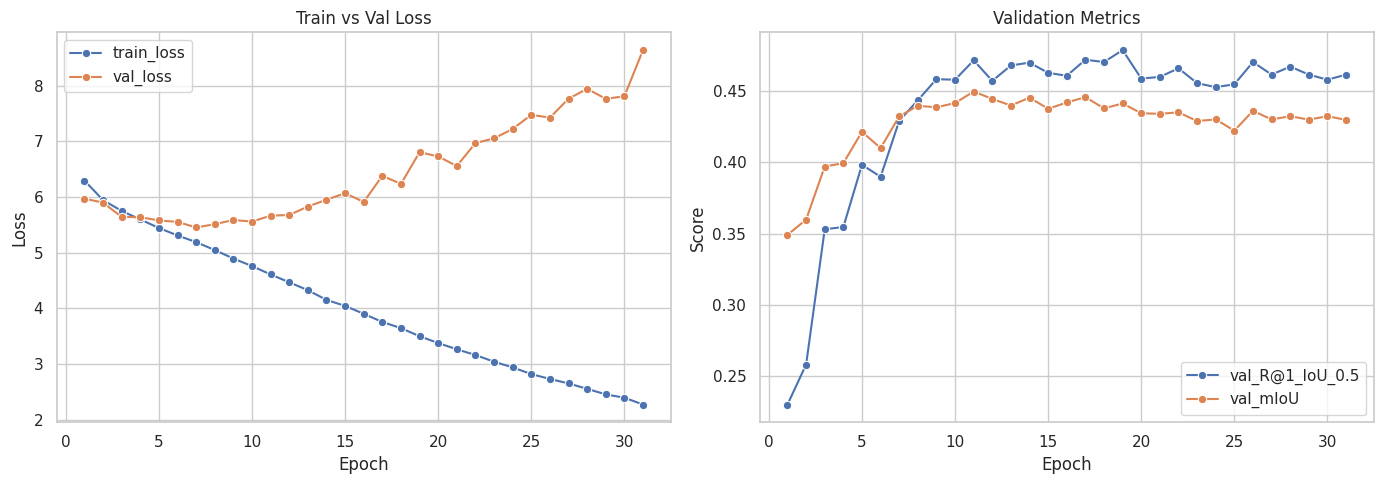

saved history csv to /content/drive/MyDrive/momentlens_runs/charades_vslnet_phase3/run_003/history.csv
saved training curves to /content/drive/MyDrive/momentlens_runs/charades_vslnet_phase3/run_003/training_curves.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

history_df = pd.DataFrame(history)
history_csv_path = RUN_ROOT / 'history.csv'
history_df.to_csv(history_csv_path, index=False)

sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.lineplot(data=history_df, x='epoch', y='train_loss', marker='o', ax=axes[0], label='train_loss')
sns.lineplot(data=history_df, x='epoch', y='val_loss', marker='o', ax=axes[0], label='val_loss')
axes[0].set_title('Train vs Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

sns.lineplot(data=history_df, x='epoch', y='val_R@1_IoU_0.5', marker='o', ax=axes[1], label='val_R@1_IoU_0.5')
sns.lineplot(data=history_df, x='epoch', y='val_mIoU', marker='o', ax=axes[1], label='val_mIoU')
axes[1].set_title('Validation Metrics')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Score')
axes[1].legend()

fig.tight_layout()
training_curves_path = RUN_ROOT / 'training_curves.png'
fig.savefig(training_curves_path, dpi=200, bbox_inches='tight')
plt.show()

print('saved history csv to', history_csv_path)
print('saved training curves to', training_curves_path)


In [ ]:
import math
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

try:
    import cv2
except Exception:
    cv2 = None

QUAL_ROOT = RUN_ROOT / 'qualitative_examples'
QUAL_ROOT.mkdir(parents=True, exist_ok=True)

records = test_records


def build_video_file_index():
    index = {}
    for path in RAW_VIDEO_ROOT.rglob('*'):
        if path.suffix.lower() in ['.mp4', '.avi', '.mkv', '.webm']:
            index.setdefault(path.stem, str(path))
    return index


video_files = build_video_file_index()
rng = random.Random(42)
np_rng = np.random.default_rng(42)


def weighted_sample(pool, target, n, used):
    candidates = [r for r in pool if r['sample_idx'] not in used]
    if not candidates:
        return []
    temperature = 0.12
    scores = np.array([abs(r['iou'] - target) for r in candidates], dtype=np.float32)
    weights = np.exp(-scores / temperature)
    weights = weights / weights.sum()
    picked = []
    available = candidates[:]
    available_weights = weights[:]
    for _ in range(min(n, len(available))):
        idx = int(np_rng.choice(len(available), p=available_weights))
        rec = available.pop(idx)
        available_weights = np.delete(available_weights, idx)
        if available_weights.size > 0:
            available_weights = available_weights / available_weights.sum()
        picked.append(rec)
        used.add(rec['sample_idx'])
    return picked


def choose_examples_around_targets(records):
    used = set()
    low_pool = [r for r in records if 0.00 <= r['iou'] <= 0.30]
    mid_pool = [r for r in records if 0.30 <= r['iou'] <= 0.70]
    high_pool = [r for r in records if 0.70 <= r['iou'] <= 1.00]
    low = weighted_sample(low_pool, target=0.10, n=5, used=used)
    mid = weighted_sample(mid_pool, target=0.50, n=5, used=used)
    high = weighted_sample(high_pool, target=0.90, n=5, used=used)

    def fill(group, target):
        if len(group) >= 5:
            return group[:5]
        remaining = [r for r in records if r['sample_idx'] not in used]
        remaining = sorted(remaining, key=lambda r: abs(r['iou'] - target))
        for rec in remaining:
            group.append(rec)
            used.add(rec['sample_idx'])
            if len(group) == 5:
                break
        return group[:5]

    return {
        'low': fill(low, 0.10),
        'mid': fill(mid, 0.50),
        'high': fill(high, 0.90),
    }


def write_video_clip(src_path, out_path, start_sec, end_sec, pad_sec=0.5):
    src_path = Path(src_path)
    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    if out_path.exists():
        out_path.unlink()
    if cv2 is None:
        raise RuntimeError('cv2 is not available in this runtime')

    cap = cv2.VideoCapture(str(src_path))
    if not cap.isOpened():
        raise RuntimeError(f'Unable to open video: {src_path}')

    fps = float(cap.get(cv2.CAP_PROP_FPS) or 24.0)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT) or 0)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH) or 0)
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT) or 0)
    if width <= 0 or height <= 0:
        cap.release()
        raise RuntimeError(f'Invalid frame size for: {src_path}')

    start_sec = max(0.0, float(start_sec) - pad_sec)
    end_sec = float(end_sec) + pad_sec
    start_frame = max(0, int(math.floor(start_sec * fps)))
    end_frame = int(math.ceil(end_sec * fps))
    if frame_count > 0:
        end_frame = min(end_frame, frame_count - 1)

    cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)
    writer = cv2.VideoWriter(str(out_path), cv2.VideoWriter_fourcc(*'mp4v'), fps, (width, height))

    current = start_frame
    while current <= end_frame:
        ok, frame = cap.read()
        if not ok:
            break
        writer.write(frame)
        current += 1

    cap.release()
    writer.release()


def save_timeline_plot(record, out_path):
    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    fig, ax = plt.subplots(figsize=(10, 2.4))
    max_time = max(record['duration'], record['gt_end'], record['pred_end']) + 0.5
    ax.axvspan(0, max_time, color='lightgray', alpha=0.12)
    ax.axvspan(record['gt_start'], record['gt_end'], color='tab:green', alpha=0.35, label='GT')
    ax.axvspan(record['pred_start'], record['pred_end'], color='tab:orange', alpha=0.35, label='Pred')
    ax.set_xlim(0, max_time)
    ax.set_yticks([])
    ax.set_xlabel('Time (s)')
    ax.set_title(f"{record['group']} | {record['video_id']} | IoU={record['iou']:.3f}")
    ax.legend(loc='upper right')
    fig.tight_layout()
    fig.savefig(out_path, dpi=200, bbox_inches='tight')
    plt.close(fig)


groups = choose_examples_around_targets(records)
summary = {k: len(v) for k, v in groups.items()}

with open(RUN_ROOT / 'qualitative_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

for group, group_records in groups.items():
    group_dir = QUAL_ROOT / group
    group_dir.mkdir(parents=True, exist_ok=True)

    for rank, record in enumerate(group_records, 1):
        case_id = f"{record['sample_id']}_{rank:02d}"
        case_dir = group_dir / case_id
        case_dir.mkdir(parents=True, exist_ok=True)

        src_video = Path(video_files[record['video_id']])
        shutil.copy2(src_video, case_dir / 'original.mp4')
        write_video_clip(src_video, case_dir / 'gt_clip.mp4', record['gt_start'], record['gt_end'], pad_sec=0.5)
        write_video_clip(src_video, case_dir / 'pred_clip.mp4', record['pred_start'], record['pred_end'], pad_sec=0.5)

        save_timeline_plot({**record, 'group': group}, case_dir / 'timeline.png')

        metadata = {
            **record,
            'group': group,
            'rank_in_group': rank,
            'video_path': str(src_video),
        }
        with open(case_dir / 'metadata.json', 'w') as f:
            json.dump(metadata, f, indent=2)

print(json.dumps(summary, indent=2))
print('saved qualitative examples to', QUAL_ROOT)


{
  "low": 5,
  "mid": 5,
  "high": 5
}
saved qualitative examples to /content/drive/MyDrive/momentlens_runs/charades_vslnet_phase3/run_003/qualitative_examples


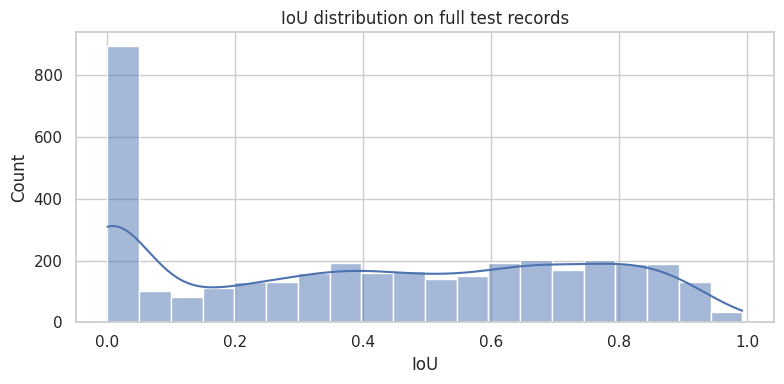

{
  "num_records": 3720,
  "iou_min": 0.0,
  "iou_max": 0.992366373538971,
  "iou_mean": 0.41165218002416987,
  "iou_median": 0.41538460552692413
}

Bucket counts:
iou_bucket  count
     0-0.1    996
   0.1-0.3    462
   0.3-0.5    689
   0.5-0.7    677
   0.7-0.9    761
   0.9-1.0    135

Worst 10:
 sample_idx video_id  iou  gt_start    gt_end  pred_start  pred_end                                         query
        684    75M1Z  0.0 25.900000 31.334000         0.5      19.5        person sat on the sofa to read a book.
       2383    BYP85  0.0 21.799999 29.799999         4.5      13.5 person they tidy up a shelf in front of them.
        626    7ZL8E  0.0 16.500000 25.900000         0.5      12.5               a person takes off their shoes.
        628    7ZL8E  0.0 16.500000 25.900000        10.5      15.5                 person takes off their shoes.
       2939    NAZ52  0.0 21.299999 27.200001         0.5      12.5                        person closes the box.
       2942    

In [ ]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

records = test_records

df = pd.DataFrame(records)
survey_dir = RUN_ROOT / 'iou_survey'
survey_dir.mkdir(parents=True, exist_ok=True)

summary = {
    'num_records': int(len(df)),
    'iou_min': float(df['iou'].min()),
    'iou_max': float(df['iou'].max()),
    'iou_mean': float(df['iou'].mean()),
    'iou_median': float(df['iou'].median()),
}

bins = [0.0, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0]
labels = ['0-0.1', '0.1-0.3', '0.3-0.5', '0.5-0.7', '0.7-0.9', '0.9-1.0']
df['iou_bucket'] = pd.cut(df['iou'], bins=bins, labels=labels, include_lowest=True)
bucket_counts = df['iou_bucket'].value_counts().sort_index().reset_index()
bucket_counts.columns = ['iou_bucket', 'count']
df['dist_to_05'] = (df['iou'] - 0.5).abs()

df.to_csv(survey_dir / 'iou_survey_records.csv', index=False)
bucket_counts.to_csv(survey_dir / 'iou_bucket_counts.csv', index=False)
with open(survey_dir / 'iou_survey_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

sns.set_theme(style='whitegrid')
plt.figure(figsize=(8, 4))
sns.histplot(df['iou'], bins=20, kde=True)
plt.title('IoU distribution on full test records')
plt.xlabel('IoU')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(survey_dir / 'iou_hist.png', dpi=200, bbox_inches='tight')
plt.show()

print(json.dumps(summary, indent=2))
print('\nBucket counts:')
print(bucket_counts.to_string(index=False))

print('\nWorst 10:')
print(df.sort_values('iou', ascending=True).head(10)[['sample_idx', 'video_id', 'iou', 'gt_start', 'gt_end', 'pred_start', 'pred_end', 'query']].to_string(index=False))

print('\nBest 10:')
print(df.sort_values('iou', ascending=False).head(10)[['sample_idx', 'video_id', 'iou', 'gt_start', 'gt_end', 'pred_start', 'pred_end', 'query']].to_string(index=False))

print('\nClosest to 0.5:')
print(df.sort_values('dist_to_05', ascending=True).head(10)[['sample_idx', 'video_id', 'iou', 'gt_start', 'gt_end', 'pred_start', 'pred_end', 'query']].to_string(index=False))

print('Saved survey files to:', survey_dir)
